# Fase 10 — Conclusiones y recomendaciones accionables (Shorts vs. largos)

Desarrolla en profundidad los 7 puntos de conclusión de la Fase 9, cada uno con su análisis completo y un veredicto derivado directamente de los datos (no texto fijo). Usa comparaciones por **día de la semana** (no fechas puntuales) allí donde corresponde, siguiendo el mismo criterio aplicado ya al notebook anterior: con solo 30 días de datos, una fecha concreta es ruido; un patrón por día de la semana es más robusto.

**Requisito previo:** base de datos `golazo_growup` cargada (`python -m src.cargar_datos`).

## 0. Carga de datos y columnas derivadas

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

from src import db_connection as dbc

url = dbc.DATABASE_URL or (
    f"postgresql+psycopg2://{dbc.DB_CONFIG['user']}:{dbc.DB_CONFIG['password']}"
    f"@{dbc.DB_CONFIG['host']}:{dbc.DB_CONFIG['port']}/{dbc.DB_CONFIG['dbname']}"
)
if url.startswith('postgresql://'):
    url = url.replace('postgresql://', 'postgresql+psycopg2://', 1)
engine = create_engine(url)

canal = pd.read_sql('SELECT * FROM canal', engine)
video = pd.read_sql('SELECT * FROM video', engine, parse_dates=['fecha_publicacion'])
video_tag = pd.read_sql('SELECT * FROM video_tag', engine)
evolucion = pd.read_sql('SELECT * FROM evolucion_diaria', engine, parse_dates=['fecha'])
retencion = pd.read_sql('SELECT * FROM retencion_audiencia', engine)
ingresos = pd.read_sql('SELECT * FROM ingresos', engine, parse_dates=['fecha'])

ORDEN_DIAS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

evolucion['dia_semana'] = evolucion['fecha'].dt.day_name()
evolucion['suscriptores_netos'] = evolucion['subscribers_gained'] - evolucion['subscribers_lost']

UMBRAL_SHORT_SEGUNDOS = 180  # YouTube: máximo de un Short desde octubre de 2024
video['es_short'] = video['duracion_segundos'] <= UMBRAL_SHORT_SEGUNDOS
video['formato'] = video['es_short'].map({True: 'Short', False: 'Largo'})
video['dia_semana_publicacion'] = video['fecha_publicacion'].dt.day_name()
video['ratio_likes_vista'] = video['likes'] / video['views_totales']
video['ratio_comentarios_vista'] = video['comentarios'] / video['views_totales']

video['z_views_categoria_formato'] = video.groupby(['categoria', 'formato'])['views_totales'].transform(
    lambda s: (s - s.mean()) / s.std() if s.std() > 0 else 0
)

fecha_corte = video['fecha_publicacion'].max() - pd.Timedelta(days=30)
video['es_reciente'] = video['fecha_publicacion'] > fecha_corte

retencion_media_por_video = retencion.groupby('video_id')['audience_watch_ratio'].mean().rename('retencion_media')
video = video.merge(retencion_media_por_video, on='video_id', how='left')

print(f'Vídeos: {len(video)} ({(video["formato"]=="Short").sum()} Shorts, {(video["formato"]=="Largo").sum()} largos)')

Vídeos: 338 (83 Shorts, 255 largos)


## 1. Días fuertes: ¿qué formato empuja realmente el pico de audiencia?

Se identifica el día de la semana con más audiencia media histórica y se comprueba qué formato predomina entre lo publicado ese día — para no asumir que 'publicar más' basta, sin importar qué se publique.

In [2]:
patron_semanal_audiencia = evolucion.groupby('dia_semana')[
    ['views', 'subscribers_gained', 'subscribers_lost', 'suscriptores_netos']
].mean().reindex(ORDEN_DIAS)

top2_dias_semana_audiencia = patron_semanal_audiencia.sort_values('views', ascending=False).head(2)
dias_semana_top_audiencia = top2_dias_semana_audiencia.index.tolist()
print('Los 2 días de la semana con mayor audiencia media histórica:')
display(top2_dias_semana_audiencia.round(1))

Los 2 días de la semana con mayor audiencia media histórica:


,views,subscribers_gained,subscribers_lost,suscriptores_netos
dia_semana,,,,
Saturday,13890.2,41.4,5.6,35.8
Sunday,13230.8,39.4,5.6,33.8


In [3]:
videos_dias_top = video[video['dia_semana_publicacion'].isin(dias_semana_top_audiencia)]
reparto_formato_dias_top = videos_dias_top['formato'].value_counts()
print(f"Vídeos publicados históricamente en {dias_semana_top_audiencia}: {len(videos_dias_top)}")
display(reparto_formato_dias_top)

if len(reparto_formato_dias_top):
    formato_dominante = reparto_formato_dias_top.idxmax()
    pct_dominante = reparto_formato_dias_top.max() / reparto_formato_dias_top.sum() * 100
    print(f"\nVEREDICTO: el {pct_dominante:.0f}% de lo publicado en los días fuertes es de tipo "
          f"'{formato_dominante}'. La recomendación no es 'publicar más' en esos días, sino concretamente "
          f"reforzar contenido de tipo {formato_dominante} en esa ventana.")
else:
    print('\nSin vídeos publicados en esos días de la semana para determinar el formato dominante.')

Vídeos publicados históricamente en ['Saturday', 'Sunday']: 96


formato
Largo    71
Short    25
Name: count, dtype: int64


VEREDICTO: el 74% de lo publicado en los días fuertes es de tipo 'Largo'. La recomendación no es 'publicar más' en esos días, sino concretamente reforzar contenido de tipo Largo en esa ventana.


## 2. Categoría Afición: ¿potenciarla, y en qué formato?

Comparación Shorts-con-Shorts y largos-con-largos frente al resto del canal — la decisión de potenciar la categoría se toma por formato, no de forma global.

In [4]:
aficion = video[video['categoria'] == 'Afición']
print(f'Vídeos de Afición: {len(aficion)} de {len(video)} totales')
display(aficion['formato'].value_counts())

veredicto_aficion = {}
for formato in ['Short', 'Largo']:
    grupo_aficion = aficion[aficion['formato'] == formato]
    grupo_resto = video[(video['categoria'] != 'Afición') & (video['formato'] == formato)]
    if len(grupo_aficion) == 0 or len(grupo_resto) == 0:
        print(f'\n{formato}: datos insuficientes para comparar (Afición={len(grupo_aficion)}, resto={len(grupo_resto)}).')
        continue

    views_aficion, views_resto = grupo_aficion['views_totales'].mean(), grupo_resto['views_totales'].mean()
    ret_aficion, ret_resto = grupo_aficion['retencion_media'].mean(), grupo_resto['retencion_media'].mean()
    supera = views_aficion > views_resto and ret_aficion > ret_resto
    veredicto_aficion[formato] = supera

    print(f"\n--- {formato}: Afición (n={len(grupo_aficion)}) vs. resto {formato.lower()}s (n={len(grupo_resto)}) ---")
    print(f"  Vistas medias: {views_aficion:.0f} vs. {views_resto:.0f}")
    print(f"  Retención media: {ret_aficion*100:.1f}% vs. {ret_resto*100:.1f}%")
    print(f"  VEREDICTO: {'SÍ potenciar' if supera else 'NO potenciar'} Afición en formato {formato} "
          f"({'supera' if supera else 'no supera'} a su propio equivalente de formato en el canal).")

Vídeos de Afición: 17 de 338 totales


formato
Largo    13
Short     4
Name: count, dtype: int64


--- Short: Afición (n=4) vs. resto shorts (n=79) ---
  Vistas medias: 2593 vs. 7074
  Retención media: 35.6% vs. 38.9%
  VEREDICTO: NO potenciar Afición en formato Short (no supera a su propio equivalente de formato en el canal).

--- Largo: Afición (n=13) vs. resto largos (n=242) ---
  Vistas medias: 4419 vs. 5150
  Retención media: 38.2% vs. 39.0%
  VEREDICTO: NO potenciar Afición en formato Largo (no supera a su propio equivalente de formato en el canal).


## 3. Vídeos virales: detección corregida por categoría + formato

In [5]:
picos_virales = video[video['z_views_categoria_formato'] > 2]
print(f'Vídeos con vistas anormalmente altas para su categoría Y formato: {len(picos_virales)} de {len(video)}')
display(picos_virales['formato'].value_counts())

Vídeos con vistas anormalmente altas para su categoría Y formato: 18 de 338


formato
Largo    17
Short     1
Name: count, dtype: int64

In [6]:
for formato in ['Short', 'Largo']:
    virales_formato = video[(video['z_views_categoria_formato'] > 2) & (video['formato'] == formato)]
    resto_formato = video[(video['z_views_categoria_formato'] <= 2) & (video['formato'] == formato)]
    if len(virales_formato) == 0:
        print(f'\nNo hay vídeos virales de tipo {formato}.')
        continue

    print(f"\n--- {formato}s virales (n={len(virales_formato)}) vs. resto de {formato.lower()}s (n={len(resto_formato)}) ---")
    print(f"  Retención media: {virales_formato['retencion_media'].mean()*100:.1f}% vs. {resto_formato['retencion_media'].mean()*100:.1f}%")
    print(f"  Likes/vista: {virales_formato['ratio_likes_vista'].mean()*100:.2f}% vs. {resto_formato['ratio_likes_vista'].mean()*100:.2f}%")
    print(f"  Categoría dominante: {virales_formato['categoria'].mode().iloc[0]}")

    dia_dominante_viral = virales_formato['dia_semana_publicacion'].mode().iloc[0]
    coincide = dia_dominante_viral in dias_semana_top_audiencia
    print(f"  Día de semana dominante: {dia_dominante_viral} "
          f"({'coincide' if coincide else 'NO coincide'} con los días de mayor audiencia histórica)")

    retiene_mejor = virales_formato['retencion_media'].mean() > resto_formato['retencion_media'].mean()
    print(f"  VEREDICTO: {'éxito replicable (retiene mejor, no solo más vistas)' if retiene_mejor else 'probable golpe de alcance puntual (no retiene mejor)'}"
          f"{' + refuerzo de calendario' if coincide and retiene_mejor else ''}.")


--- Shorts virales (n=1) vs. resto de shorts (n=82) ---
  Retención media: 36.7% vs. 38.8%
  Likes/vista: 3.17% vs. 3.71%
  Categoría dominante: Seguimiento del club
  Día de semana dominante: Thursday (NO coincide con los días de mayor audiencia histórica)
  VEREDICTO: probable golpe de alcance puntual (no retiene mejor).

--- Largos virales (n=17) vs. resto de largos (n=238) ---
  Retención media: 38.9% vs. 39.0%
  Likes/vista: 3.63% vs. 3.76%
  Categoría dominante: Seguimiento del club
  Día de semana dominante: Sunday (coincide con los días de mayor audiencia histórica)
  VEREDICTO: probable golpe de alcance puntual (no retiene mejor).


## 4. Top 5 de vídeos "perfectos" — uno por formato

Score normalizado dentro de cada formato (alcance + engagement + retención), para que cada Top 5 sirva de referencia a su propia línea de producción.

In [7]:
def normalizar(serie):
    rango = serie.max() - serie.min()
    return (serie - serie.min()) / rango if rango > 0 else serie * 0

tops_por_formato = {}
for formato in ['Short', 'Largo']:
    grupo = video[video['formato'] == formato].copy()
    grupo['score_perfecto'] = (
        normalizar(grupo['views_totales']) * 0.35
        + normalizar(grupo['likes']) * 0.25
        + normalizar(grupo['comentarios']) * 0.15
        + normalizar(grupo['retencion_media']) * 0.25
    )
    top5 = grupo.sort_values('score_perfecto', ascending=False).head(5)
    tops_por_formato[formato] = top5
    print(f'\nTOP 5 {formato}s "perfectos" (de {len(grupo)}):')
    display(top5[['titulo', 'categoria', 'views_totales', 'likes', 'comentarios',
                   'retencion_media', 'score_perfecto']].round(3))


TOP 5 Shorts "perfectos" (de 83):


,titulo,categoria,views_totales,likes,comentarios,retencion_media,score_perfecto
111,Nuestra opinión tras el partido #112,Opinión post-partido,20016,688,183,0.442,0.936
79,Nuestra opinión tras el partido #80,Opinión post-partido,18822,661,201,0.428,0.891
304,Nuestra opinión tras el partido #305,Opinión post-partido,16840,813,91,0.446,0.858
0,Nuestra opinión tras el partido #1,Opinión post-partido,19844,650,97,0.439,0.849
225,Análisis del partido - Jornada 226,Seguimiento del club,16025,742,127,0.427,0.809



TOP 5 Largos "perfectos" (de 255):


,titulo,categoria,views_totales,likes,comentarios,retencion_media,score_perfecto
292,Curiosidad futbolística #293,Curiosidades de fútbol,18125,747,225,0.431,0.918
168,Análisis del partido - Jornada 169,Seguimiento del club,19849,668,173,0.435,0.897
258,Rumores de fichajes: novedad #259,Fichajes,17967,744,150,0.399,0.800
45,Análisis del partido - Jornada 46,Seguimiento del club,17127,812,166,0.382,0.784
198,Análisis del partido - Jornada 199,Seguimiento del club,18378,572,116,0.420,0.774


In [8]:
# Categoría más repetida en cada Top 5 -> referencia de producción por formato
for formato, top5 in tops_por_formato.items():
    categoria_referencia = top5['categoria'].mode().iloc[0]
    print(f"Referencia de producción para {formato}: categoría '{categoria_referencia}' "
          f"({(top5['categoria'] == categoria_referencia).sum()} de 5 en el Top 5).")

Referencia de producción para Short: categoría 'Opinión post-partido' (4 de 5 en el Top 5).
Referencia de producción para Largo: categoría 'Seguimiento del club' (3 de 5 en el Top 5).


## 5. Ganancia de suscriptores: ¿qué formato convierte espectador en suscriptor?

Igual que en el punto 1, se usa el día de la semana con más ganancia media de suscriptores (no una fecha puntual), y se mira qué formato predomina en lo publicado ese día.

In [9]:
patron_semanal_subs = evolucion.groupby('dia_semana')['subscribers_gained'].mean().reindex(ORDEN_DIAS)
dia_top_subs = patron_semanal_subs.idxmax()
print('Suscriptores ganados de media, por día de la semana:')
display(patron_semanal_subs.round(2))
print(f"\nDía de la semana con más ganancia media de suscriptores: {dia_top_subs}")

Suscriptores ganados de media, por día de la semana:


dia_semana
Monday       25.00
Tuesday      21.25
Wednesday    24.25
Thursday     22.75
Friday       30.75
Saturday     41.40
Sunday       39.40
Name: subscribers_gained, dtype: float64


Día de la semana con más ganancia media de suscriptores: Saturday


In [10]:
videos_dia_top_subs = video[video['dia_semana_publicacion'] == dia_top_subs]
reparto_formato_subs = videos_dia_top_subs['formato'].value_counts()
print(f'Vídeos publicados históricamente en {dia_top_subs}: {len(videos_dia_top_subs)}')
display(reparto_formato_subs)

if len(reparto_formato_subs):
    formato_conversor = reparto_formato_subs.idxmax()
    print(f"\nVEREDICTO: el formato predominante en el día que más suscriptores genera es "
          f"'{formato_conversor}'. Es la pista más fuerte de qué tipo de contenido convierte "
          f"espectador en suscriptor, no solo en vista puntual.")
else:
    print('\nSin vídeos publicados ese día de la semana para determinar el formato conversor.')

Vídeos publicados históricamente en Saturday: 44


formato
Largo    30
Short    14
Name: count, dtype: int64


VEREDICTO: el formato predominante en el día que más suscriptores genera es 'Largo'. Es la pista más fuerte de qué tipo de contenido convierte espectador en suscriptor, no solo en vista puntual.


## 6. Calendario de publicación vs. audiencia real — por formato

Si Shorts y largos tienen calendarios distintos, una única recomendación de canal ('publicad más en sábado') puede ser correcta para uno y errónea para el otro.

In [11]:
esperado_sin_sesgo = 100 / 7
veredicto_calendario = {}

for formato in ['Short', 'Largo']:
    grupo = video[video['formato'] == formato]
    distribucion = grupo['dia_semana_publicacion'].value_counts(normalize=True).mul(100).reindex(ORDEN_DIAS).fillna(0)
    pct_dia_top = distribucion.get(dias_semana_top_audiencia[0], 0)
    diferencia_pp = esperado_sin_sesgo - pct_dia_top

    print(f"\n--- {formato}s (n={len(grupo)}) — % publicado en {dias_semana_top_audiencia[0]} (día de más audiencia) ---")
    display(distribucion.round(1))

    if diferencia_pp > 3:
        veredicto_calendario[formato] = 'desalineado (publica de menos en el día fuerte)'
    elif diferencia_pp < -3:
        veredicto_calendario[formato] = 'ya alineado (sobrerrepresenta el día fuerte)'
    else:
        veredicto_calendario[formato] = 'neutro (sin desviación relevante)'
    print(f"VEREDICTO {formato}: {veredicto_calendario[formato]}")

if veredicto_calendario.get('Short') != veredicto_calendario.get('Largo'):
    print('\nCONCLUSIÓN CLAVE: Shorts y largos NO comparten el mismo diagnóstico de calendario — '
          'la recomendación de mover publicaciones al día fuerte debe aplicarse por formato, no como '
          'política única de canal.')
else:
    print('\nAmbos formatos comparten el mismo diagnóstico de calendario — en este caso sí es razonable '
          'tratarlo como una única política de canal.')


--- Shorts (n=83) — % publicado en Saturday (día de más audiencia) ---


dia_semana_publicacion
Monday       16.9
Tuesday      16.9
Wednesday    13.3
Thursday     13.3
Friday        9.6
Saturday     16.9
Sunday       13.3
Name: proportion, dtype: float64

VEREDICTO Short: neutro (sin desviación relevante)

--- Largos (n=255) — % publicado en Saturday (día de más audiencia) ---


dia_semana_publicacion
Monday       13.7
Tuesday      13.7
Wednesday    14.1
Thursday     16.5
Friday       14.1
Saturday     11.8
Sunday       16.1
Name: proportion, dtype: float64

VEREDICTO Largo: neutro (sin desviación relevante)

Ambos formatos comparten el mismo diagnóstico de calendario — en este caso sí es razonable tratarlo como una única política de canal.


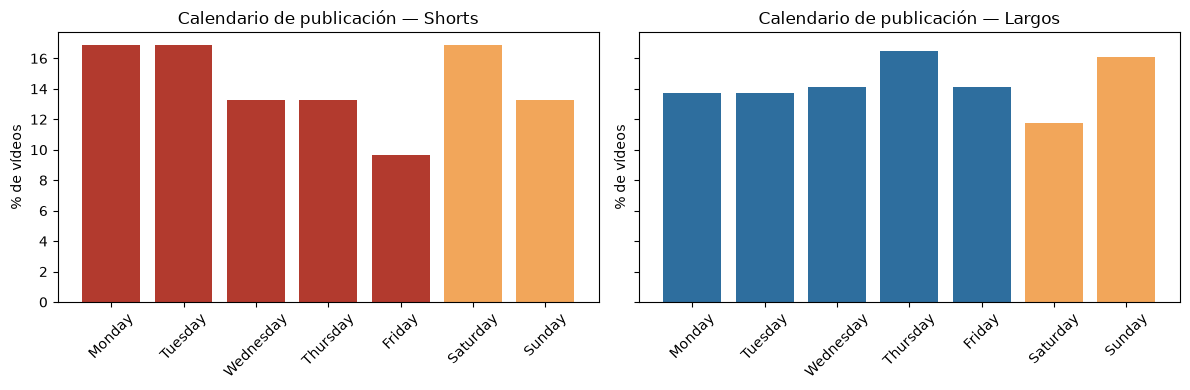

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, formato, color in zip(axes, ['Short', 'Largo'], ['#B23A2E', '#2E6E9E']):
    grupo = video[video['formato'] == formato]
    dist = grupo['dia_semana_publicacion'].value_counts(normalize=True).mul(100).reindex(ORDEN_DIAS).fillna(0)
    colores = [color if d not in dias_semana_top_audiencia else '#F2A65A' for d in ORDEN_DIAS]
    ax.bar(ORDEN_DIAS, dist.values, color=colores)
    ax.set_title(f'Calendario de publicación — {formato}s')
    ax.set_ylabel('% de vídeos')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Tendencia y mezcla de formatos: ¿los Shorts explican la caída de ingresos?

In [13]:
# Tendencia de la mezcla de formatos a lo largo del tiempo (bloques cronológicos de 50 vídeos)
video_ordenado = video.sort_values('fecha_publicacion').reset_index(drop=True)
video_ordenado['bloque_50'] = video_ordenado.index // 50
mezcla_por_bloque = video_ordenado.groupby('bloque_50')['es_short'].mean() * 100
print('% de Shorts por bloques de 50 vídeos consecutivos (orden cronológico):')
display(mezcla_por_bloque.round(1))

bloques_num = np.arange(len(mezcla_por_bloque))
pendiente_mezcla, _ = np.polyfit(bloques_num, mezcla_por_bloque.values, 1) if len(mezcla_por_bloque) > 1 else (0, 0)
print(f"\nTendencia de la mezcla de formatos: {pendiente_mezcla:+.2f} puntos de %Shorts por bloque "
      f"({'creciente' if pendiente_mezcla > 0 else 'decreciente' if pendiente_mezcla < 0 else 'estable'}).")

% de Shorts por bloques de 50 vídeos consecutivos (orden cronológico):


bloque_50
0    26.0
1    26.0
2    28.0
3    28.0
4    16.0
5    22.0
6    26.3
Name: es_short, dtype: float64


Tendencia de la mezcla de formatos: -0.68 puntos de %Shorts por bloque (decreciente).


In [14]:
# Tendencia de ingreso diario del canal (nivel canal, no se puede partir por formato:
# ingresos es un agregado del canal completo, no distingue qué formato generó las vistas del día)
dias_num = np.arange(len(evolucion))
pendiente_ingresos, _ = np.polyfit(dias_num, ingresos.sort_values('fecha')['estimated_revenue'], 1)
print(f"Tendencia de ingreso diario del canal: {pendiente_ingresos:+.3f} EUR/día "
      f"({'creciente' if pendiente_ingresos > 0 else 'decreciente' if pendiente_ingresos < 0 else 'estable'}).")

if pendiente_mezcla > 0 and pendiente_ingresos < 0:
    print('\nVEREDICTO: el canal está produciendo más Shorts recientemente Y el ingreso cae en el mismo '
          'periodo. Esto NO prueba causalidad, pero es una hipótesis a investigar antes de recomendar más '
          'Shorts como solución genérica al problema económico del cliente.')
elif pendiente_mezcla > 0 and pendiente_ingresos >= 0:
    print('\nVEREDICTO: el canal produce más Shorts recientemente y el ingreso NO cae — no hay indicio de '
          'que el cambio de mezcla esté perjudicando la monetización.')
else:
    print('\nVEREDICTO: no hay una tendencia creciente de Shorts que investigar como causa de la caída '
          'de ingresos en este periodo.')

Tendencia de ingreso diario del canal: -0.023 EUR/día (decreciente).

VEREDICTO: no hay una tendencia creciente de Shorts que investigar como causa de la caída de ingresos en este periodo.


## Resumen ejecutivo de veredictos

*(Se genera a partir de las variables calculadas arriba — revisa que todas las celdas se hayan ejecutado en orden antes de leer este resumen.)*

In [15]:
print('RESUMEN DE VEREDICTOS')
print('=' * 70)
print(f"1. Días fuertes ({dias_semana_top_audiencia}): formato dominante -> "
      f"{reparto_formato_dias_top.idxmax() if len(reparto_formato_dias_top) else 'sin datos'}")
for formato, decision in veredicto_aficion.items():
    print(f"2. Afición ({formato}): {'potenciar' if decision else 'no potenciar'}")
print(f"3. Vídeos virales detectados (corregidos por formato): {len(picos_virales)}")
for formato in tops_por_formato:
    print(f"4. Top 5 {formato}: referencia = '{tops_por_formato[formato]['categoria'].mode().iloc[0]}'")
print(f"5. Día que más suscriptores genera: {dia_top_subs} -> formato predominante: "
      f"{reparto_formato_subs.idxmax() if len(reparto_formato_subs) else 'sin datos'}")
print(f"6. Calendario -> Shorts: {veredicto_calendario.get('Short', 'sin datos')} | "
      f"Largos: {veredicto_calendario.get('Largo', 'sin datos')}")
print(f"7. Mezcla de formatos {'creciente' if pendiente_mezcla > 0 else 'decreciente'} en Shorts, "
      f"ingreso {'creciente' if pendiente_ingresos > 0 else 'decreciente'} -> "
      f"{'investigar relación' if pendiente_mezcla > 0 and pendiente_ingresos < 0 else 'sin alarma'}")

RESUMEN DE VEREDICTOS
1. Días fuertes (['Saturday', 'Sunday']): formato dominante -> Largo
2. Afición (Short): no potenciar
2. Afición (Largo): no potenciar
3. Vídeos virales detectados (corregidos por formato): 18
4. Top 5 Short: referencia = 'Opinión post-partido'
4. Top 5 Largo: referencia = 'Seguimiento del club'
5. Día que más suscriptores genera: Saturday -> formato predominante: Largo
6. Calendario -> Shorts: neutro (sin desviación relevante) | Largos: neutro (sin desviación relevante)
7. Mezcla de formatos decreciente en Shorts, ingreso decreciente -> sin alarma
